# FX Volatility Surface Analysis - EUR/USD

Notebook Python construit à partir du README du projet.

Objectif : reconstruire une surface de volatilité implicite FX à partir de quotes de marché standard
(ATM, Risk Reversal, Butterfly), analyser le skew et le smile, suivre leur dynamique dans le temps,
puis montrer des applications desk pour le pricing, le relative value et le hedging.

Le notebook utilise directement le fichier `data.csv` du dossier. Ce CSV contient des quotes EUR/USD
par maturité avec les colonnes `tenor`, `atm_vol`, `rr25`, `bf25`, `rr10`, `bf10`.

## 0. Initialisation

Cette cellule charge les bibliothèques et fixe les paramètres de marché.

Convention utilisée dans le notebook :

- paire : EUR/USD ;
- volatilités en points de vol, par exemple `7.25` signifie `7.25%` ;
- `25D RR = vol(25D call EUR) - vol(25D put EUR)` ;
- `25D BF = (vol(25D call EUR) + vol(25D put EUR)) / 2 - vol(ATM)`.

In [40]:
from pathlib import Path
import os
import math
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import PchipInterpolator
from scipy.stats import norm

warnings.filterwarnings("ignore", category=RuntimeWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("seaborn-v0_8-whitegrid")

In [41]:
AS_OF_DATE = pd.Timestamp("2026-04-24")

# Paramètres spot/rates paramétrables.
SPOT_EURUSD = 1.0725
USD_RATE = 0.0425   # taux domestique pour EUR/USD, approximation USD
EUR_RATE = 0.0275   # taux étranger pour EUR/USD, approximation EUR

print(f"As of date : {AS_OF_DATE.date()}")
print(f"Spot EUR/USD : {SPOT_EURUSD:.4f}")
print(f"USD rate : {USD_RATE:.2%} | EUR rate : {EUR_RATE:.2%}")

As of date : 2026-04-24
Spot EUR/USD : 1.0725
USD rate : 4.25% | EUR rate : 2.75%


## 1. Données de marché ATM / Risk Reversal / Butterfly

Sur un desk FX options, les volatilités sont souvent cotées par maturité avec :

- une volatilité ATM ;
- un Risk Reversal, qui mesure le déséquilibre call versus put ;
- un Butterfly, qui mesure la convexité du smile.

Le notebook accepte un CSV avec les colonnes suivantes :

`tenor, atm_vol, rr25, bf25, rr10, bf10`

In [42]:
def tenor_to_years(tenor: str) -> float:
    tenor = tenor.strip().upper()
    unit = tenor[-1]
    value = float(tenor[:-1])

    if unit == "D":
        return value / 365.0
    if unit == "W":
        return 7.0 * value / 365.0
    if unit == "M":
        return value / 12.0
    if unit == "Y":
        return value
    raise ValueError(f"Tenor non reconnu : {tenor}")


sample_quotes = pd.DataFrame(
    [
        {"tenor": "1W", "atm_vol": 7.35, "rr25": -0.10, "bf25": 0.18, "rr10": -0.30, "bf10": 0.55},
        {"tenor": "2W", "atm_vol": 7.20, "rr25": -0.15, "bf25": 0.20, "rr10": -0.38, "bf10": 0.60},
        {"tenor": "1M", "atm_vol": 7.05, "rr25": -0.25, "bf25": 0.24, "rr10": -0.55, "bf10": 0.72},
        {"tenor": "2M", "atm_vol": 6.90, "rr25": -0.32, "bf25": 0.27, "rr10": -0.70, "bf10": 0.80},
        {"tenor": "3M", "atm_vol": 6.85, "rr25": -0.42, "bf25": 0.31, "rr10": -0.90, "bf10": 0.92},
        {"tenor": "6M", "atm_vol": 7.05, "rr25": -0.55, "bf25": 0.37, "rr10": -1.15, "bf10": 1.05},
        {"tenor": "9M", "atm_vol": 7.20, "rr25": -0.62, "bf25": 0.43, "rr10": -1.28, "bf10": 1.15},
        {"tenor": "1Y", "atm_vol": 7.35, "rr25": -0.70, "bf25": 0.50, "rr10": -1.42, "bf10": 1.28},
        {"tenor": "18M", "atm_vol": 7.55, "rr25": -0.78, "bf25": 0.58, "rr10": -1.58, "bf10": 1.42},
    ]
)

# Le projet utilise maintenant le CSV fourni dans le dossier.
CSV_PATH = "data.csv"


def read_quotes_csv(csv_path: str) -> pd.DataFrame:
    path = Path(csv_path)
    if not path.exists():
        raise FileNotFoundError(f"CSV introuvable : {path.resolve()}")

    # data.csv utilise un séparateur ';', une virgule décimale et peut contenir un BOM UTF-8.
    df = pd.read_csv(path, sep=";", decimal=",", encoding="utf-8-sig")
    df.columns = df.columns.str.strip().str.lower()

    for col in ["atm_vol", "rr25", "bf25", "rr10", "bf10"]:
        if df[col].dtype == "object":
            df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")

    return df


def load_market_quotes(csv_path=None) -> pd.DataFrame:
    required = {"tenor", "atm_vol", "rr25", "bf25", "rr10", "bf10"}

    if csv_path is None:
        df = sample_quotes.copy()
    else:
        df = read_quotes_csv(csv_path)

    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans les quotes : {sorted(missing)}")

    df = df.copy()
    df["tenor"] = df["tenor"].astype(str).str.upper().str.strip()
    numeric_cols = ["atm_vol", "rr25", "bf25", "rr10", "bf10"]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    if df[numeric_cols].isna().any().any():
        bad_rows = df[df[numeric_cols].isna().any(axis=1)]
        raise ValueError(f"Valeurs numériques invalides dans le CSV :\n{bad_rows}")

    df["maturity_years"] = df["tenor"].map(tenor_to_years)
    df["forward"] = SPOT_EURUSD * np.exp((USD_RATE - EUR_RATE) * df["maturity_years"])
    df = df.sort_values("maturity_years").reset_index(drop=True)
    return df


market_quotes = load_market_quotes(CSV_PATH)
market_quotes

,tenor,atm_vol,rr25,bf25,rr10,bf10,maturity_years,forward
0,1D,5.0250,-0.4150,0.1800,-0.7900,0.6050,0.0027,1.0725
1,1W,6.7350,-0.5550,0.2300,-1.0500,0.8200,0.0192,1.0728
2,2W,6.3100,-0.4650,0.2350,-0.8950,0.8400,0.0384,1.0731
3,3W,6.1175,-0.4025,0.2500,-0.7925,0.8875,0.0575,1.0734
4,1M,5.8550,-0.3525,0.2575,-0.7050,0.9150,0.0833,1.0738
5,2M,6.0000,-0.2600,0.2700,-0.5000,0.9900,0.1667,1.0752
6,3M,6.0350,-0.1950,0.2850,-0.3550,1.0600,0.2500,1.0765
7,4M,6.0825,-0.1000,0.3025,-0.1800,1.1175,0.3333,1.0779
8,5M,6.1370,-0.0405,0.3125,-0.0640,1.1575,0.4167,1.0792
9,6M,6.1500,0.0025,0.3175,0.0200,1.1800,0.5000,1.0806


## 2. Conversion des quotes FX en volatilités par delta et par strike

À partir de `ATM`, `RR` et `BF`, on reconstruit les volatilités des ailes :

- `vol_call = ATM + BF + RR / 2`
- `vol_put = ATM + BF - RR / 2`

Ensuite, chaque delta est converti en strike avec une formule Black/Garman-Kohlhagen en delta forward.
Cette étape transforme le langage de cotation trader en points exploitables pour une surface `strike x maturité`.

Hypothèse importante : le notebook utilise une convention ATM delta-neutral. Si la source du CSV cote l'ATM forward, il faut remplacer le strike ATM par le forward `F`.

In [43]:
def add_wing_vols(quotes: pd.DataFrame) -> pd.DataFrame:
    out = quotes.copy()

    out["vol_25d_call"] = out["atm_vol"] + out["bf25"] + 0.5 * out["rr25"]
    out["vol_25d_put"] = out["atm_vol"] + out["bf25"] - 0.5 * out["rr25"]
    out["vol_10d_call"] = out["atm_vol"] + out["bf10"] + 0.5 * out["rr10"]
    out["vol_10d_put"] = out["atm_vol"] + out["bf10"] - 0.5 * out["rr10"]

    wing_cols = ["vol_10d_put", "vol_25d_put", "atm_vol", "vol_25d_call", "vol_10d_call"]
    if (out[wing_cols] <= 0).any().any():
        raise ValueError("Une volatilité reconstruite est négative ou nulle. Vérifie les quotes RR/BF.")

    return out


market_quotes = add_wing_vols(market_quotes)
cols = [
    "tenor",
    "maturity_years",
    "forward",
    "atm_vol",
    "rr25",
    "bf25",
    "vol_25d_put",
    "vol_25d_call",
    "rr10",
    "bf10",
    "vol_10d_put",
    "vol_10d_call",
]
market_quotes[cols]

,tenor,maturity_years,forward,atm_vol,rr25,bf25,vol_25d_put,vol_25d_call,rr10,bf10,vol_10d_put,vol_10d_call
0,1D,0.0027,1.0725,5.0250,-0.4150,0.1800,5.4125,4.9975,-0.7900,0.6050,6.0250,5.2350
1,1W,0.0192,1.0728,6.7350,-0.5550,0.2300,7.2425,6.6875,-1.0500,0.8200,8.0800,7.0300
2,2W,0.0384,1.0731,6.3100,-0.4650,0.2350,6.7775,6.3125,-0.8950,0.8400,7.5975,6.7025
3,3W,0.0575,1.0734,6.1175,-0.4025,0.2500,6.5687,6.1662,-0.7925,0.8875,7.4013,6.6087
4,1M,0.0833,1.0738,5.8550,-0.3525,0.2575,6.2888,5.9363,-0.7050,0.9150,7.1225,6.4175
5,2M,0.1667,1.0752,6.0000,-0.2600,0.2700,6.4000,6.1400,-0.5000,0.9900,7.2400,6.7400
6,3M,0.2500,1.0765,6.0350,-0.1950,0.2850,6.4175,6.2225,-0.3550,1.0600,7.2725,6.9175
7,4M,0.3333,1.0779,6.0825,-0.1000,0.3025,6.4350,6.3350,-0.1800,1.1175,7.2900,7.1100
8,5M,0.4167,1.0792,6.1370,-0.0405,0.3125,6.4697,6.4292,-0.0640,1.1575,7.3265,7.2625
9,6M,0.5000,1.0806,6.1500,0.0025,0.3175,6.4663,6.4688,0.0200,1.1800,7.3200,7.3400


In [44]:
def strike_from_forward_delta(forward: float, vol_pct: float, maturity_years: float, n_d1: float) -> float:
    vol = vol_pct / 100.0
    std = max(vol * math.sqrt(maturity_years), 1e-10)
    d1 = norm.ppf(n_d1)
    return forward * math.exp(0.5 * vol * vol * maturity_years - std * d1)


def build_smile_points(quotes: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in quotes.iterrows():
        buckets = [
            # n_d1 élevé -> put OTM, strike plus bas que le forward.
            {"bucket": "10D Put", "delta_bucket": -0.10, "n_d1": 0.90, "vol_pct": row["vol_10d_put"]},
            {"bucket": "25D Put", "delta_bucket": -0.25, "n_d1": 0.75, "vol_pct": row["vol_25d_put"]},
            {"bucket": "ATM", "delta_bucket": 0.00, "n_d1": 0.50, "vol_pct": row["atm_vol"]},
            {"bucket": "25D Call", "delta_bucket": 0.25, "n_d1": 0.25, "vol_pct": row["vol_25d_call"]},
            {"bucket": "10D Call", "delta_bucket": 0.10, "n_d1": 0.10, "vol_pct": row["vol_10d_call"]},
        ]

        for bucket in buckets:
            strike = strike_from_forward_delta(
                forward=row["forward"],
                vol_pct=bucket["vol_pct"],
                maturity_years=row["maturity_years"],
                n_d1=bucket["n_d1"],
            )

            rows.append(
                {
                    "tenor": row["tenor"],
                    "maturity_years": row["maturity_years"],
                    "forward": row["forward"],
                    "bucket": bucket["bucket"],
                    "delta_bucket": bucket["delta_bucket"],
                    "strike": strike,
                    "strike_over_spot": strike / SPOT_EURUSD,
                    "log_moneyness": math.log(strike / row["forward"]),
                    "vol_pct": bucket["vol_pct"],
                }
            )

    return pd.DataFrame(rows).sort_values(["maturity_years", "strike"]).reset_index(drop=True)


smile_points = build_smile_points(market_quotes)
smile_points.head(15)

,tenor,maturity_years,forward,bucket,delta_bucket,strike,strike_over_spot,log_moneyness,vol_pct
0,1D,0.0027,1.0725,10D Put,-0.1000,1.0682,0.9960,-0.0040,6.0250
1,1D,0.0027,1.0725,25D Put,-0.2500,1.0705,0.9981,-0.0019,5.4125
2,1D,0.0027,1.0725,ATM,0.0000,1.0725,1.0000,0.0000,5.0250
3,1D,0.0027,1.0725,25D Call,0.2500,1.0744,1.0018,0.0018,4.9975
4,1D,0.0027,1.0725,10D Call,0.1000,1.0763,1.0036,0.0035,5.2350
5,1W,0.0192,1.0728,10D Put,-0.1000,1.0576,0.9861,-0.0143,8.0800
6,1W,0.0192,1.0728,25D Put,-0.2500,1.0656,0.9936,-0.0067,7.2425
7,1W,0.0192,1.0728,ATM,0.0000,1.0729,1.0003,0.0000,6.7350
8,1W,0.0192,1.0728,25D Call,0.2500,1.0796,1.0066,0.0063,6.6875
9,1W,0.0192,1.0728,10D Call,0.1000,1.0863,1.0129,0.0125,7.0300


## 3. Reconstruction de la surface implicite

La surface est reconstruite en deux dimensions :

- interpolation du smile en log-moneyness pour chaque maturité ;
- interpolation en maturité sur la variance totale, plus stable que l'interpolation directe de la volatilité.

Le résultat donne une fonction `surface_vol_pct(T, K)` utilisable ensuite pour le pricing.

In [45]:
def forward_at(maturity_years: float) -> float:
    return SPOT_EURUSD * np.exp((USD_RATE - EUR_RATE) * maturity_years)


def make_smile_interpolators(smile_df: pd.DataFrame):
    interpolators = {}
    bounds = {}

    for maturity, group in smile_df.groupby("maturity_years"):
        g = group.sort_values("log_moneyness")
        x = g["log_moneyness"].to_numpy()
        y = g["vol_pct"].to_numpy()

        interpolators[float(maturity)] = PchipInterpolator(x, y, extrapolate=True)
        bounds[float(maturity)] = (float(x.min()), float(x.max()))

    return interpolators, bounds


smile_interpolators, smile_bounds = make_smile_interpolators(smile_points)
market_maturities = np.array(sorted(smile_interpolators.keys()))


def surface_vol_pct(maturity_years: float, strike):
    scalar_input = np.isscalar(strike)
    strikes = np.atleast_1d(np.asarray(strike, dtype=float))
    out = []

    for k in strikes:
        total_variances = []

        for market_t in market_maturities:
            raw_x = math.log(k / forward_at(market_t))
            lo, hi = smile_bounds[market_t]
            x = min(max(raw_x, lo), hi)
            vol = float(smile_interpolators[market_t](x))
            vol = max(vol, 0.01) / 100.0
            total_variances.append(vol * vol * market_t)

        total_variances = np.maximum(np.asarray(total_variances), 1e-10)
        maturity_interp = PchipInterpolator(market_maturities, total_variances, extrapolate=True)
        total_var = max(float(maturity_interp(maturity_years)), 1e-10)
        out.append(math.sqrt(total_var / max(maturity_years, 1e-10)) * 100.0)

    out = np.asarray(out)
    return float(out[0]) if scalar_input else out


maturity_grid = np.linspace(market_maturities.min(), market_maturities.max(), 90)

# Avec des quotes jusqu'à 30Y, K/Spot devient peu lisible à cause du différentiel de taux.
# La surface est donc tracée en log-moneyness ln(K/F), plus comparable entre maturités.
x_min = smile_points["log_moneyness"].min()
x_max = smile_points["log_moneyness"].max()
x_pad = 0.03 * (x_max - x_min)
log_moneyness_grid = np.linspace(x_min - x_pad, x_max + x_pad, 130)

surface_matrix = np.empty((len(maturity_grid), len(log_moneyness_grid)))
for i, maturity in enumerate(maturity_grid):
    strikes = forward_at(maturity) * np.exp(log_moneyness_grid)
    surface_matrix[i, :] = surface_vol_pct(maturity, strikes)

surface_df = pd.DataFrame(surface_matrix, index=maturity_grid, columns=log_moneyness_grid)
surface_df.iloc[::12, ::24].round(3)

,-0.5438,-0.2832,-0.0227,0.2378,0.4984,0.7589
0.0027,6.0250,6.0250,6.0250,5.2350,5.2350,5.2350
4.0473,8.8360,8.8360,7.5500,8.9310,9.0510,9.0510
8.0919,8.8540,8.8060,7.9200,8.5320,9.3100,9.2790
12.1365,8.9100,8.5890,8.0880,8.5340,9.3750,9.5020
16.1810,8.9540,8.4670,8.1580,8.4790,9.3160,9.5570
20.2256,8.9190,8.4570,8.1660,8.4110,9.0970,9.5750
24.2702,8.8930,8.3980,8.1700,8.3520,8.9710,9.6420
28.3148,8.8730,8.3550,8.1720,8.3180,8.8770,9.5020


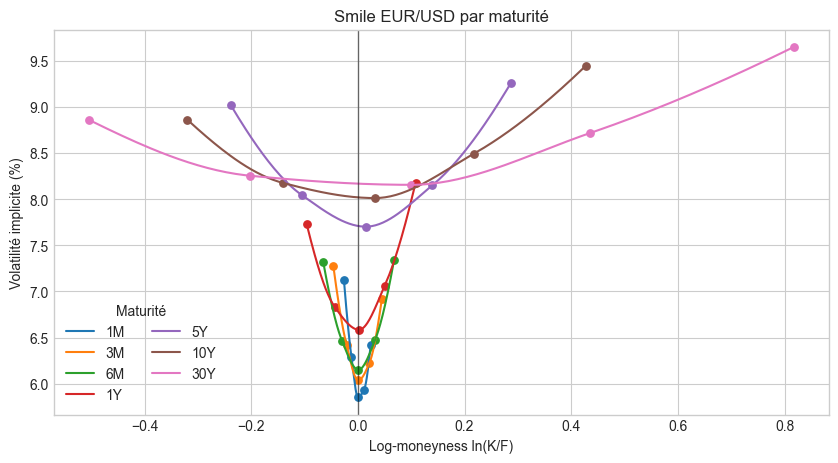

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))

tenors_to_plot = ["1M", "3M", "6M", "1Y", "5Y", "10Y", "30Y"]
for tenor in tenors_to_plot:
    if tenor not in set(smile_points["tenor"]):
        continue

    g = smile_points[smile_points["tenor"] == tenor].sort_values("log_moneyness")
    maturity = float(g["maturity_years"].iloc[0])
    x_dense = np.linspace(g["log_moneyness"].min(), g["log_moneyness"].max(), 150)
    vol_dense = smile_interpolators[maturity](x_dense)

    ax.plot(x_dense, vol_dense, label=tenor)
    ax.scatter(g["log_moneyness"], g["vol_pct"], s=28)

ax.axvline(0.0, color="black", linewidth=1, alpha=0.5)
ax.set_title("Smile EUR/USD par maturité")
ax.set_xlabel("Log-moneyness ln(K/F)")
ax.set_ylabel("Volatilité implicite (%)")
ax.legend(title="Maturité", ncol=2)
plt.show()

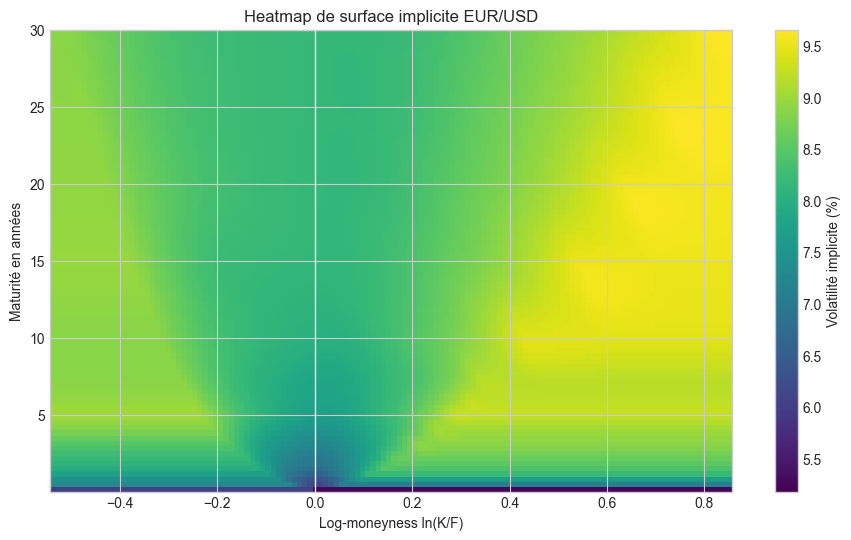

In [47]:
fig, ax = plt.subplots(figsize=(11, 6))

im = ax.imshow(
    surface_matrix,
    origin="lower",
    aspect="auto",
    extent=[log_moneyness_grid.min(), log_moneyness_grid.max(), maturity_grid.min(), maturity_grid.max()],
    cmap="viridis",
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Volatilité implicite (%)")

ax.set_title("Heatmap de surface implicite EUR/USD")
ax.set_xlabel("Log-moneyness ln(K/F)")
ax.set_ylabel("Maturité en années")
ax.axvline(0.0, color="white", linewidth=1, alpha=0.8)
plt.show()

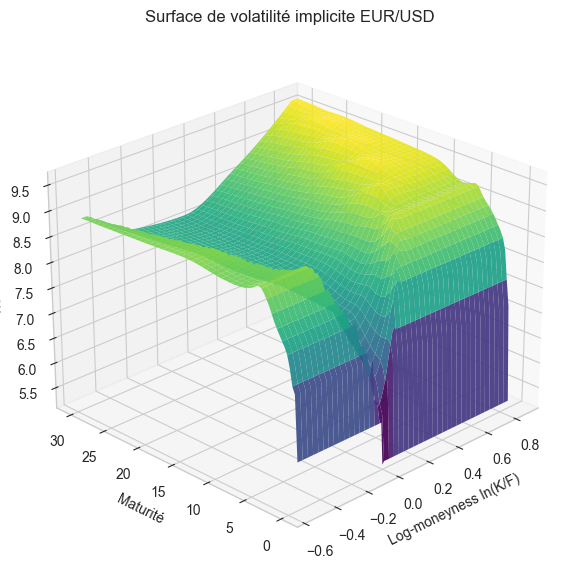

In [48]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

log_moneyness_mesh, maturity_mesh = np.meshgrid(log_moneyness_grid, maturity_grid)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(
    log_moneyness_mesh,
    maturity_mesh,
    surface_matrix,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.92,
)
ax.set_title("Surface de volatilité implicite EUR/USD")
ax.set_xlabel("Log-moneyness ln(K/F)")
ax.set_ylabel("Maturité")
ax.set_zlabel("Vol (%)")
ax.view_init(elev=25, azim=-135)
plt.show()

### Surface 3D interactive

Cette cellule affiche la surface en 3D avec Plotly. Tu peux tourner la surface, zoomer et survoler les points cotés.

In [49]:
import plotly.graph_objects as go

# Version interactive de la surface : x = log-moneyness, y = maturité, z = volatilité.
fig3d = go.Figure()

fig3d.add_trace(
    go.Surface(
        x=log_moneyness_grid,
        y=maturity_grid,
        z=surface_matrix,
        colorscale="Viridis",
        colorbar=dict(title="Vol (%)"),
        hovertemplate=(
            "ln(K/F): %{x:.3f}<br>"
            "Maturité: %{y:.2f}Y<br>"
            "Vol: %{z:.2f}%<extra></extra>"
        ),
        name="Surface interpolée",
    )
)

fig3d.add_trace(
    go.Scatter3d(
        x=smile_points["log_moneyness"],
        y=smile_points["maturity_years"],
        z=smile_points["vol_pct"],
        mode="markers",
        marker=dict(size=3.5, color="white", line=dict(color="black", width=0.8)),
        text=smile_points["tenor"] + " - " + smile_points["bucket"],
        hovertemplate=(
            "%{text}<br>"
            "ln(K/F): %{x:.3f}<br>"
            "Maturité: %{y:.2f}Y<br>"
            "Vol cotée: %{z:.2f}%<extra></extra>"
        ),
        name="Points de marché",
    )
)

fig3d.update_layout(
    title="Surface de volatilité implicite EUR/USD - 3D interactive",
    width=950,
    height=700,
    scene=dict(
        xaxis_title="Log-moneyness ln(K/F)",
        yaxis_title="Maturité (années)",
        zaxis_title="Vol implicite (%)",
        camera=dict(eye=dict(x=-1.55, y=-1.75, z=0.85)),
    ),
    margin=dict(l=0, r=0, t=55, b=0),
)

fig3d.show()

## 3bis. Contrôles de cohérence

Ces tests vérifient les points clés avant d'interpréter la surface :

- volatilités reconstruites positives ;
- strikes ordonnés du put OTM vers le call OTM ;
- convexité cohérente entre 10D et 25D ;
- intensité du 10D RR supérieure au 25D RR ;
- absence de violation évidente de variance totale croissante en maturité sur une grille de strikes fixes.

In [50]:
def calendar_total_variance_check(n_strikes: int = 40) -> tuple[int, float]:
    fixed_strikes = np.linspace(
        smile_points["strike"].quantile(0.02),
        smile_points["strike"].quantile(0.98),
        n_strikes,
    )

    violations = 0
    min_diff = np.inf

    for strike in fixed_strikes:
        total_variance = np.array(
            [
                (surface_vol_pct(maturity, strike) / 100.0) ** 2 * maturity
                for maturity in market_maturities
            ]
        )
        diffs = np.diff(total_variance)
        min_diff = min(min_diff, float(diffs.min()))
        violations += int((diffs < -1e-8).sum())

    return violations, min_diff


wing_cols = ["vol_10d_put", "vol_25d_put", "atm_vol", "vol_25d_call", "vol_10d_call"]
positive_wings = bool((market_quotes[wing_cols] > 0).all().all())

expected_bucket_order = ["10D Put", "25D Put", "ATM", "25D Call", "10D Call"]
strike_order_ok = True
for _, group in smile_points.groupby("tenor"):
    strikes = [group.loc[group["bucket"] == bucket, "strike"].iloc[0] for bucket in expected_bucket_order]
    strike_order_ok &= all(strikes[i] < strikes[i + 1] for i in range(len(strikes) - 1))

calendar_violations, min_calendar_diff = calendar_total_variance_check()

coherence_report = pd.DataFrame(
    [
        {
            "controle": "Volatilités reconstruites positives",
            "ok": positive_wings,
            "detail": f"Min wing vol = {market_quotes[wing_cols].min().min():.4f}%",
        },
        {
            "controle": "Ordre des strikes par delta",
            "ok": strike_order_ok,
            "detail": "10D put < 25D put < ATM < 25D call < 10D call",
        },
        {
            "controle": "BF 10D supérieur au BF 25D",
            "ok": bool((market_quotes["bf10"] >= market_quotes["bf25"]).all()),
            "detail": f"Min(BF10 - BF25) = {(market_quotes['bf10'] - market_quotes['bf25']).min():.4f}",
        },
        {
            "controle": "|RR 10D| supérieur à |RR 25D|",
            "ok": bool((market_quotes["rr10"].abs() >= market_quotes["rr25"].abs()).all()),
            "detail": f"Min spread = {(market_quotes['rr10'].abs() - market_quotes['rr25'].abs()).min():.4f}",
        },
        {
            "controle": "Variance totale croissante en maturité",
            "ok": calendar_violations == 0,
            "detail": f"Violations = {calendar_violations}, min diff = {min_calendar_diff:.2e}",
        },
    ]
)

coherence_report

,controle,ok,detail
0,Volatilités reconstruites positives,True,Min wing vol = 4.9975%
1,Ordre des strikes par delta,True,10D put < 25D put < ATM < 25D call < 10D call
2,BF 10D supérieur au BF 25D,True,Min(BF10 - BF25) = 0.4250
3,|RR 10D| supérieur à |RR 25D|,True,Min spread = 0.0175
4,Variance totale croissante en maturité,True,"Violations = 0, min diff = 6.47e-05"


## 4. Analyse desk du skew et du smile

Interprétation utilisée :

- `RR > 0` : les calls EUR sont plus chers que les puts EUR, biais haussier EUR ;
- `RR < 0` : les puts EUR sont plus chers, demande de protection EUR downside ;
- `BF élevé` : demande de convexité / tail risk ;
- `BF bas` : marché plus complaisant sur les extrêmes.

In [51]:
def rr_interpretation(rr: float) -> str:
    if rr > 0.15:
        return "Calls EUR payés : biais haussier EUR"
    if rr < -0.15:
        return "Puts EUR payés : protection downside EUR"
    return "Skew proche de neutre"


def bf_interpretation(bf: float) -> str:
    if bf > 0.55:
        return "Convexité élevée : tail risk cher"
    if bf < 0.25:
        return "Convexité basse : marché plus complaisant"
    return "Convexité intermédiaire"


smile_analysis = market_quotes[["tenor", "maturity_years", "atm_vol", "rr25", "bf25", "rr10", "bf10"]].copy()
smile_analysis["lecture_rr25"] = smile_analysis["rr25"].map(rr_interpretation)
smile_analysis["lecture_bf25"] = smile_analysis["bf25"].map(bf_interpretation)
smile_analysis

,tenor,maturity_years,atm_vol,rr25,bf25,rr10,bf10,lecture_rr25,lecture_bf25
0,1D,0.0027,5.0250,-0.4150,0.1800,-0.7900,0.6050,Puts EUR payés : protection downside EUR,Convexité basse : marché plus complaisant
1,1W,0.0192,6.7350,-0.5550,0.2300,-1.0500,0.8200,Puts EUR payés : protection downside EUR,Convexité basse : marché plus complaisant
2,2W,0.0384,6.3100,-0.4650,0.2350,-0.8950,0.8400,Puts EUR payés : protection downside EUR,Convexité basse : marché plus complaisant
3,3W,0.0575,6.1175,-0.4025,0.2500,-0.7925,0.8875,Puts EUR payés : protection downside EUR,Convexité intermédiaire
4,1M,0.0833,5.8550,-0.3525,0.2575,-0.7050,0.9150,Puts EUR payés : protection downside EUR,Convexité intermédiaire
5,2M,0.1667,6.0000,-0.2600,0.2700,-0.5000,0.9900,Puts EUR payés : protection downside EUR,Convexité intermédiaire
6,3M,0.2500,6.0350,-0.1950,0.2850,-0.3550,1.0600,Puts EUR payés : protection downside EUR,Convexité intermédiaire
7,4M,0.3333,6.0825,-0.1000,0.3025,-0.1800,1.1175,Skew proche de neutre,Convexité intermédiaire
8,5M,0.4167,6.1370,-0.0405,0.3125,-0.0640,1.1575,Skew proche de neutre,Convexité intermédiaire
9,6M,0.5000,6.1500,0.0025,0.3175,0.0200,1.1800,Skew proche de neutre,Convexité intermédiaire


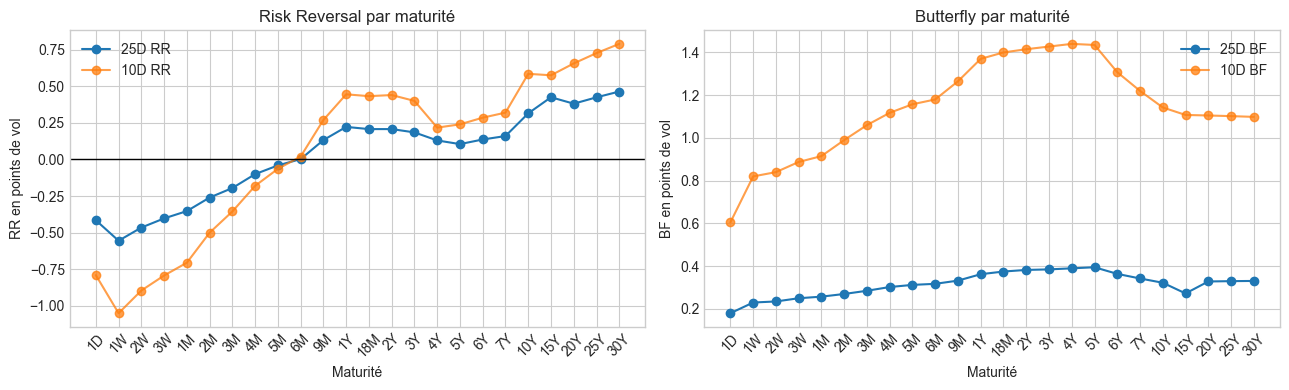

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

axes[0].plot(market_quotes["tenor"], market_quotes["rr25"], marker="o", label="25D RR")
axes[0].plot(market_quotes["tenor"], market_quotes["rr10"], marker="o", label="10D RR", alpha=0.75)
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_title("Risk Reversal par maturité")
axes[0].set_ylabel("RR en points de vol")
axes[0].legend()

axes[1].plot(market_quotes["tenor"], market_quotes["bf25"], marker="o", label="25D BF")
axes[1].plot(market_quotes["tenor"], market_quotes["bf10"], marker="o", label="10D BF", alpha=0.75)
axes[1].set_title("Butterfly par maturité")
axes[1].set_ylabel("BF en points de vol")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Maturité")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Dynamique temporelle et dashboard z-score

Un desk ne regarde pas uniquement le niveau actuel : il regarde le mouvement de la surface.

Comme le dossier ne contient pas d'historique réel, la cellule suivante crée un historique synthétique cohérent
avec les quotes courantes. Pour passer en données réelles, remplace `history` par un DataFrame contenant :

`date, tenor, atm_vol, rr25, bf25`

In [53]:
def simulate_history(current_quotes: pd.DataFrame, as_of_date: pd.Timestamp, n_days: int = 260, seed: int = 7) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(end=as_of_date, periods=n_days)
    rows = []

    metric_cfg = {
        "atm_vol": {"rho": 0.96, "sigma": 0.07, "amp": 0.40, "floor": 1.0},
        "rr25": {"rho": 0.94, "sigma": 0.035, "amp": 0.16, "floor": None},
        "bf25": {"rho": 0.95, "sigma": 0.025, "amp": 0.08, "floor": 0.01},
    }

    for _, quote in current_quotes.iterrows():
        tenor_factor = 1.0 + 0.10 * np.log1p(quote["maturity_years"] * 12.0)
        phase = rng.uniform(0, 2 * np.pi)
        series = {}

        for metric, cfg in metric_cfg.items():
            dev = np.zeros(n_days)
            for i in range(1, n_days):
                dev[i] = cfg["rho"] * dev[i - 1] + rng.normal(0, cfg["sigma"] * tenor_factor)

            seasonal = cfg["amp"] * np.sin(np.linspace(0, 4 * np.pi, n_days) + phase)
            raw = quote[metric] + seasonal + dev
            raw = raw - (raw[-1] - quote[metric])

            if cfg["floor"] is not None:
                raw = np.maximum(raw, cfg["floor"])

            raw[-1] = quote[metric]
            series[metric] = raw

        for i, date in enumerate(dates):
            rows.append(
                {
                    "date": date,
                    "tenor": quote["tenor"],
                    "maturity_years": quote["maturity_years"],
                    "atm_vol": series["atm_vol"][i],
                    "rr25": series["rr25"][i],
                    "bf25": series["bf25"][i],
                }
            )

    return pd.DataFrame(rows)


history = simulate_history(market_quotes, AS_OF_DATE)
history.tail(12)

,date,tenor,maturity_years,atm_vol,rr25,bf25
6228,2026-04-09,30Y,30.0000,8.5991,0.6927,0.1849
6229,2026-04-10,30Y,30.0000,8.5458,0.6814,0.1959
6230,2026-04-13,30Y,30.0000,8.5433,0.6527,0.2313
6231,2026-04-14,30Y,30.0000,8.6051,0.6630,0.2417
6232,2026-04-15,30Y,30.0000,8.4650,0.5331,0.3030
6233,2026-04-16,30Y,30.0000,8.4012,0.5844,0.2822
6234,2026-04-17,30Y,30.0000,8.2352,0.6059,0.3229
6235,2026-04-20,30Y,30.0000,8.2753,0.5719,0.3864
6236,2026-04-21,30Y,30.0000,8.1744,0.5165,0.3607
6237,2026-04-22,30Y,30.0000,8.0889,0.4446,0.3918


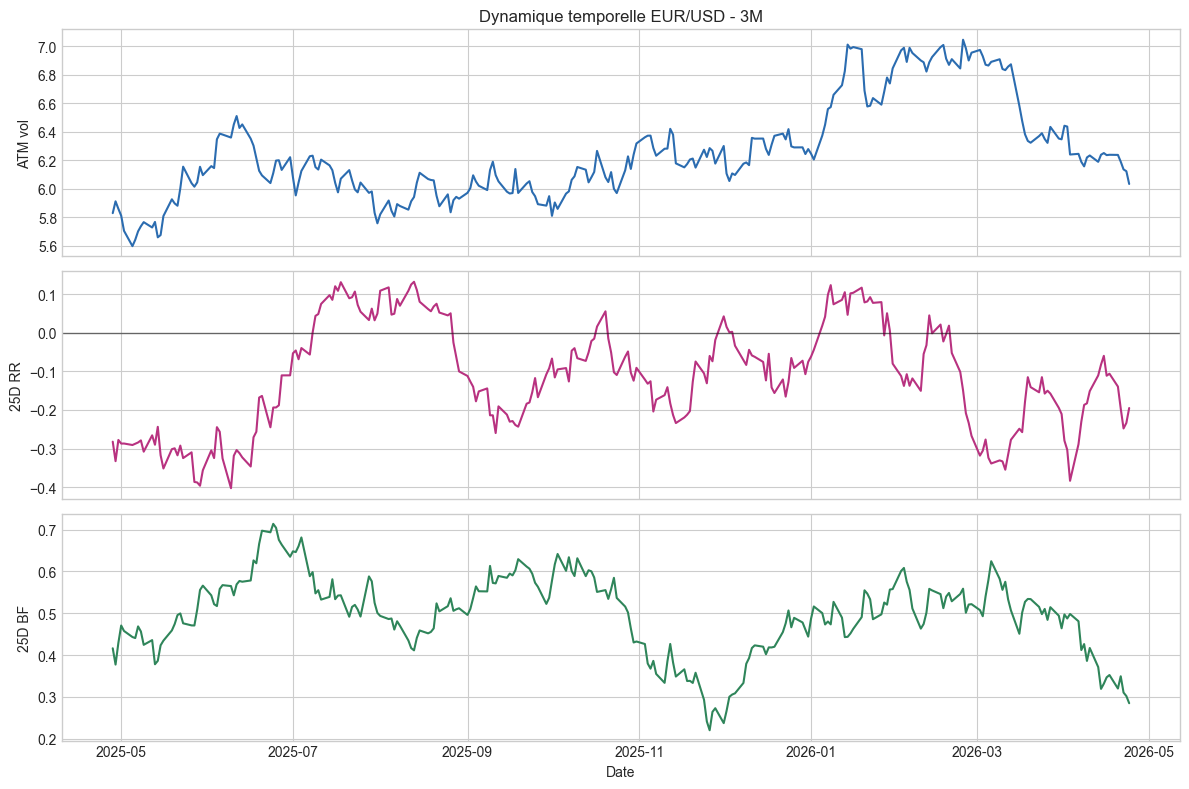

In [54]:
SELECTED_TENOR = "3M"
h = history[history["tenor"] == SELECTED_TENOR].sort_values("date")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(h["date"], h["atm_vol"], color="#2b6cb0")
axes[0].set_title(f"Dynamique temporelle EUR/USD - {SELECTED_TENOR}")
axes[0].set_ylabel("ATM vol")

axes[1].plot(h["date"], h["rr25"], color="#b83280")
axes[1].axhline(0, color="black", linewidth=1, alpha=0.5)
axes[1].set_ylabel("25D RR")

axes[2].plot(h["date"], h["bf25"], color="#2f855a")
axes[2].set_ylabel("25D BF")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

In [55]:
def build_zscore_dashboard(history: pd.DataFrame, current_quotes: pd.DataFrame) -> pd.DataFrame:
    last_date = history["date"].max()
    hist = history[history["date"] < last_date]
    records = []

    for _, current in current_quotes.iterrows():
        tenor_hist = hist[hist["tenor"] == current["tenor"]]
        for metric in ["atm_vol", "rr25", "bf25"]:
            mean = tenor_hist[metric].mean()
            std = tenor_hist[metric].std(ddof=1)
            z = (current[metric] - mean) / std if std > 0 else np.nan
            records.append(
                {
                    "tenor": current["tenor"],
                    "metric": metric,
                    "current": current[metric],
                    "hist_mean": mean,
                    "hist_std": std,
                    "z_score": z,
                }
            )

    dash = pd.DataFrame(records)

    def regime(row):
        if row["z_score"] >= 1.5:
            return "Riche vs historique"
        if row["z_score"] <= -1.5:
            return "Cheap vs historique"
        return "Dans le range"

    dash["regime"] = dash.apply(regime, axis=1)
    return dash


dashboard = build_zscore_dashboard(history, market_quotes)
dashboard.sort_values(["metric", "z_score"], ascending=[True, False]).round(3)

,tenor,metric,current,hist_mean,hist_std,z_score,regime
36,18M,atm_vol,6.8520,5.9180,0.3380,2.7670,Riche vs historique
51,6Y,atm_vol,7.7650,7.0500,0.3370,2.1210,Riche vs historique
66,25Y,atm_vol,8.1500,7.5060,0.3560,1.8090,Riche vs historique
9,3W,atm_vol,6.1180,5.5110,0.3960,1.5300,Riche vs historique
12,1M,atm_vol,5.8550,5.2880,0.3980,1.4260,Dans le range
...,...,...,...,...,...,...,...
1,1D,rr25,-0.4150,-0.2530,0.1340,-1.2100,Dans le range
25,5M,rr25,-0.0400,0.1800,0.1450,-1.5220,Cheap vs historique
46,4Y,rr25,0.1300,0.4930,0.2090,-1.7410,Cheap vs historique
61,15Y,rr25,0.4250,0.6860,0.1200,-2.1800,Cheap vs historique


In [56]:
def generate_relative_value_signals(dashboard: pd.DataFrame, threshold: float = 1.25) -> pd.DataFrame:
    signals = []

    for _, row in dashboard.iterrows():
        z = row["z_score"]
        metric = row["metric"]
        tenor = row["tenor"]

        if abs(z) < threshold:
            continue

        if metric == "rr25":
            if z > 0:
                idea = "Skew EUR calls riche : envisager short 25D call / long 25D put si vue mean reversion"
            else:
                idea = "Skew EUR puts riche : envisager long 25D call / short 25D put ou monétiser la protection"
        elif metric == "bf25":
            if z > 0:
                idea = "Convexité riche : vente de fly possible si le desk accepte le tail risk"
            else:
                idea = "Convexité cheap : achat de fly / long convexity à étudier"
        else:
            if z > 0:
                idea = "Vol ATM riche : carry de vente de vol à comparer au risque événementiel"
            else:
                idea = "Vol ATM cheap : achat de vega/gamma à étudier"

        signals.append(
            {
                "tenor": tenor,
                "metric": metric,
                "z_score": z,
                "regime": row["regime"],
                "desk_read": idea,
            }
        )

    return pd.DataFrame(signals).sort_values("z_score", key=lambda s: s.abs(), ascending=False)


rv_signals = generate_relative_value_signals(dashboard)
rv_signals.round(3)

,tenor,metric,z_score,regime,desk_read
6,18M,atm_vol,2.7670,Riche vs historique,Vol ATM riche : carry de vente de vol à compar...
19,25Y,bf25,-2.6850,Cheap vs historique,Convexité cheap : achat de fly / long convexit...
7,18M,rr25,2.3730,Riche vs historique,Skew EUR calls riche : envisager short 25D cal...
4,3M,bf25,-2.2600,Cheap vs historique,Convexité cheap : achat de fly / long convexit...
18,25Y,rr25,-2.2420,Cheap vs historique,Skew EUR puts riche : envisager long 25D call ...
15,15Y,rr25,-2.1800,Cheap vs historique,Skew EUR puts riche : envisager long 25D call ...
11,3Y,bf25,2.1370,Riche vs historique,Convexité riche : vente de fly possible si le ...
13,6Y,atm_vol,2.1210,Riche vs historique,Vol ATM riche : carry de vente de vol à compar...
20,30Y,atm_vol,-2.1210,Cheap vs historique,Vol ATM cheap : achat de vega/gamma à étudier
14,6Y,bf25,2.0980,Riche vs historique,Convexité riche : vente de fly possible si le ...


## 6. Applications pricing desk

La surface est maintenant exploitable pour mesurer l'impact du skew et du smile sur des structures simples :

- risk reversal ;
- collar ;
- option à barrière, avec un Monte Carlo simple à volatilité constante.

L'objectif ici n'est pas de remplacer une librairie de pricing de production, mais de montrer le lien direct
entre surface implicite et décision de structuration.

In [57]:
def fx_option_price(
    spot: float,
    strike: float,
    maturity_years: float,
    rd: float,
    rf: float,
    vol_dec: float,
    option_type: str,
) -> float:
    if maturity_years <= 0:
        intrinsic = max(spot - strike, 0.0) if option_type == "call" else max(strike - spot, 0.0)
        return intrinsic

    std = max(vol_dec * math.sqrt(maturity_years), 1e-12)
    d1 = (math.log(spot / strike) + (rd - rf + 0.5 * vol_dec * vol_dec) * maturity_years) / std
    d2 = d1 - std

    if option_type == "call":
        return spot * math.exp(-rf * maturity_years) * norm.cdf(d1) - strike * math.exp(-rd * maturity_years) * norm.cdf(d2)
    if option_type == "put":
        return strike * math.exp(-rd * maturity_years) * norm.cdf(-d2) - spot * math.exp(-rf * maturity_years) * norm.cdf(-d1)

    raise ValueError("option_type doit être 'call' ou 'put'")


def smile_bucket(tenor: str, bucket: str) -> pd.Series:
    result = smile_points[(smile_points["tenor"] == tenor) & (smile_points["bucket"] == bucket)]
    if result.empty:
        raise ValueError(f"Bucket introuvable : {tenor} {bucket}")
    return result.iloc[0]


PRICING_TENOR = "3M"
NOTIONAL_EUR = 1_000_000

current_row = market_quotes[market_quotes["tenor"] == PRICING_TENOR].iloc[0]
maturity = float(current_row["maturity_years"])

put_25d = smile_bucket(PRICING_TENOR, "25D Put")
call_25d = smile_bucket(PRICING_TENOR, "25D Call")

atm_vol_dec = current_row["atm_vol"] / 100.0
put_vol_smile = surface_vol_pct(maturity, put_25d["strike"]) / 100.0
call_vol_smile = surface_vol_pct(maturity, call_25d["strike"]) / 100.0

pricing_rows = []
for model, put_vol, call_vol in [
    ("Flat ATM vol", atm_vol_dec, atm_vol_dec),
    ("Surface smile", put_vol_smile, call_vol_smile),
]:
    put_price = fx_option_price(SPOT_EURUSD, put_25d["strike"], maturity, USD_RATE, EUR_RATE, put_vol, "put")
    call_price = fx_option_price(SPOT_EURUSD, call_25d["strike"], maturity, USD_RATE, EUR_RATE, call_vol, "call")

    pricing_rows.append(
        {
            "model": model,
            "tenor": PRICING_TENOR,
            "put_strike": put_25d["strike"],
            "call_strike": call_25d["strike"],
            "put_vol": put_vol * 100,
            "call_vol": call_vol * 100,
            "buy_put_premium_usd": put_price * NOTIONAL_EUR,
            "sell_call_premium_usd": call_price * NOTIONAL_EUR,
            "zero_cost_collar_net_usd": (put_price - call_price) * NOTIONAL_EUR,
            "long_call_short_put_rr_usd": (call_price - put_price) * NOTIONAL_EUR,
        }
    )

pricing_table = pd.DataFrame(pricing_rows)
pricing_table.round(2)

,model,tenor,put_strike,call_strike,put_vol,call_vol,buy_put_premium_usd,sell_call_premium_usd,zero_cost_collar_net_usd,long_call_short_put_rr_usd
0,Flat ATM vol,3M,1.0500,1.1000,6.0400,6.0400,"4,542.3600","4,551.9300",-9.5800,9.5800
1,Surface smile,3M,1.0500,1.1000,6.4200,6.2200,"5,180.8900","4,866.9200",313.9700,-313.9700


In [58]:
numeric_cols = pricing_table.select_dtypes(include="number").columns
pricing_impact = (
    pricing_table.set_index("model")[numeric_cols]
    .diff()
    .loc["Surface smile"]
    .to_frame("surface_minus_flat")
    .T
)
pricing_impact[
    [
        "put_vol",
        "call_vol",
        "buy_put_premium_usd",
        "sell_call_premium_usd",
        "zero_cost_collar_net_usd",
        "long_call_short_put_rr_usd",
    ]
].round(2)

,put_vol,call_vol,buy_put_premium_usd,sell_call_premium_usd,zero_cost_collar_net_usd,long_call_short_put_rr_usd
surface_minus_flat,0.3800,0.1900,638.5400,314.9900,323.5500,-323.5500


In [59]:
def down_and_out_call_mc(
    spot: float,
    strike: float,
    barrier: float,
    maturity_years: float,
    rd: float,
    rf: float,
    vol_dec: float,
    n_paths: int = 20_000,
    n_steps: int = 64,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)
    dt = maturity_years / n_steps
    drift = (rd - rf - 0.5 * vol_dec * vol_dec) * dt
    diffusion = vol_dec * math.sqrt(dt)

    shocks = rng.standard_normal((n_paths, n_steps))
    log_paths = math.log(spot) + np.cumsum(drift + diffusion * shocks, axis=1)
    paths = np.exp(log_paths)

    alive = paths.min(axis=1) > barrier
    payoff = np.where(alive, np.maximum(paths[:, -1] - strike, 0.0), 0.0)
    discounted = math.exp(-rd * maturity_years) * payoff

    price = discounted.mean()
    stderr = discounted.std(ddof=1) / math.sqrt(n_paths)
    return price, stderr


barrier = 0.95 * SPOT_EURUSD
barrier_strike = call_25d["strike"]
barrier_vol_flat = atm_vol_dec
barrier_vol_smile = surface_vol_pct(maturity, barrier_strike) / 100.0

barrier_rows = []
for model, vol in [("Flat ATM vol", barrier_vol_flat), ("Surface smile", barrier_vol_smile)]:
    price, stderr = down_and_out_call_mc(
        spot=SPOT_EURUSD,
        strike=barrier_strike,
        barrier=barrier,
        maturity_years=maturity,
        rd=USD_RATE,
        rf=EUR_RATE,
        vol_dec=vol,
    )

    barrier_rows.append(
        {
            "model": model,
            "tenor": PRICING_TENOR,
            "strike": barrier_strike,
            "barrier": barrier,
            "vol": vol * 100,
            "mc_price_usd_per_eur": price,
            "mc_stderr_usd_per_eur": stderr,
            "premium_usd_on_1m_eur": price * NOTIONAL_EUR,
        }
    )

barrier_table = pd.DataFrame(barrier_rows)
barrier_table.round(4)

,model,tenor,strike,barrier,vol,mc_price_usd_per_eur,mc_stderr_usd_per_eur,premium_usd_on_1m_eur
0,Flat ATM vol,3M,1.0999,1.0189,6.0350,0.0045,0.0001,"4,526.8124"
1,Surface smile,3M,1.0999,1.0189,6.2225,0.0048,0.0001,"4,839.2976"


## 7. Conclusion desk

Le projet permet de passer de quotes FX standard à une lecture directement exploitable :

- reconstruction d'une surface de volatilité implicite ;
- lecture directionnelle du Risk Reversal ;
- mesure de convexité via le Butterfly ;
- suivi historique avec z-scores ;
- impact concret sur collars, risk reversals et produits à barrière.

In [60]:
latest_rr = market_quotes.loc[market_quotes["tenor"] == "3M", "rr25"].iloc[0]
latest_bf = market_quotes.loc[market_quotes["tenor"] == "3M", "bf25"].iloc[0]

rr_read = rr_interpretation(latest_rr)
bf_read = bf_interpretation(latest_bf)

conclusion = f'''
Desk conclusion - EUR/USD vol surface

On the current EUR/USD surface, the 3M 25D Risk Reversal is {latest_rr:.2f} vol pts:
{rr_read}.

The 3M 25D Butterfly is {latest_bf:.2f} vol pts:
{bf_read}.

This project allowed me to move from a purely theoretical understanding of volatility
to a market-oriented approach. By reconstructing the FX volatility surface and analyzing
skew and smile dynamics, I can identify how the market prices directional risk and tail events,
and how these elements directly impact structuring decisions and relative value opportunities
on a trading desk.
'''

print(conclusion)


Desk conclusion - EUR/USD vol surface

On the current EUR/USD surface, the 3M 25D Risk Reversal is -0.20 vol pts:
Puts EUR payés : protection downside EUR.

The 3M 25D Butterfly is 0.28 vol pts:
Convexité intermédiaire.

This project allowed me to move from a purely theoretical understanding of volatility
to a market-oriented approach. By reconstructing the FX volatility surface and analyzing
skew and smile dynamics, I can identify how the market prices directional risk and tail events,
and how these elements directly impact structuring decisions and relative value opportunities
on a trading desk.

